# Embedding Distance Analysis: Harmful vs Benign Audio Samples

This notebook analyzes the embedding distances between harmful (AdvBench) and benign (VoiceBench) audio samples.
We visualize the embedding space to understand how the filtering selects benign samples closest to harmful ones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. Load Embeddings and Distance Data

In [2]:
# Load the analysis file with all embeddings and distances
analysis_path = Path('data/voicebench/sd-qa/sd_qa_closest_to_advbench_analysis.npz')

if analysis_path.exists():
    data = np.load(analysis_path, allow_pickle=True)
    print("Loaded analysis file with keys:", list(data.keys()))
else:
    # Fall back to loading from embedding cache
    print("Analysis file not found, loading from embedding cache...")
    vb_cache = np.load('data/embedding_cache/voicebench_embeddings_af3.npz', allow_pickle=True)
    ab_cache = np.load('data/embedding_cache/advbench_en_embeddings_af3.npz', allow_pickle=True)
    
    voicebench_embeddings = vb_cache['embeddings']
    advbench_embeddings = ab_cache['embeddings']

Loaded analysis file with keys: ['min_distances', 'all_distances', 'filtered_indices', 'voicebench_embeddings', 'advbench_embeddings', 'voicebench_files', 'advbench_files']


In [3]:
# Extract data from analysis file
if analysis_path.exists():
    voicebench_embeddings = data['voicebench_embeddings']
    advbench_embeddings = data['advbench_embeddings']
    min_distances = data['min_distances']
    all_distances = data['all_distances']
    filtered_indices = data['filtered_indices']
    
    # Try to get file names if available
    try:
        voicebench_files = data['voicebench_files']
        advbench_files = data['advbench_files']
    except:
        voicebench_files = None
        advbench_files = None

print(f"VoiceBench embeddings shape: {voicebench_embeddings.shape}")
print(f"AdvBench embeddings shape: {advbench_embeddings.shape}")
print(f"Min distances shape: {min_distances.shape}")
print(f"All distances shape: {all_distances.shape}")
print(f"Number of filtered (selected) samples: {len(filtered_indices)}")

VoiceBench embeddings shape: (6083, 3584)
AdvBench embeddings shape: (520, 3584)
Min distances shape: (6083,)
All distances shape: (6083, 520)
Number of filtered (selected) samples: 3953


## 2. Distance Statistics

In [4]:
print("=" * 60)
print("Distance Statistics (VoiceBench to nearest AdvBench)")
print("=" * 60)
print(f"Mean distance:   {min_distances.mean():.6f}")
print(f"Std deviation:   {min_distances.std():.6f}")
print(f"Minimum:         {min_distances.min():.6f}")
print(f"Maximum:         {min_distances.max():.6f}")
print(f"Median:          {np.median(min_distances):.6f}")
print()

# Percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print("Percentiles:")
for p in percentiles:
    val = np.percentile(min_distances, p)
    print(f"  {p:3d}th percentile: {val:.6f}")

Distance Statistics (VoiceBench to nearest AdvBench)
Mean distance:   0.033189
Std deviation:   0.010091
Minimum:         0.013586
Maximum:         0.137781
Median:          0.031802

Percentiles:
    1th percentile: 0.018286
    5th percentile: 0.021065
   10th percentile: 0.022596
   25th percentile: 0.026224
   50th percentile: 0.031802
   75th percentile: 0.038240
   90th percentile: 0.044468
   95th percentile: 0.049015
   99th percentile: 0.063761


In [5]:
# Statistics for selected vs non-selected samples
all_indices = np.arange(len(min_distances))
non_filtered_indices = np.setdiff1d(all_indices, filtered_indices)

selected_distances = min_distances[filtered_indices]
non_selected_distances = min_distances[non_filtered_indices]

print("=" * 60)
print("Comparison: Selected vs Non-Selected Samples")
print("=" * 60)
print(f"\nSelected samples (closest to harmful): {len(filtered_indices)}")
print(f"  Mean distance: {selected_distances.mean():.6f}")
print(f"  Std deviation: {selected_distances.std():.6f}")
print(f"  Min: {selected_distances.min():.6f}, Max: {selected_distances.max():.6f}")

print(f"\nNon-selected samples (farther from harmful): {len(non_filtered_indices)}")
print(f"  Mean distance: {non_selected_distances.mean():.6f}")
print(f"  Std deviation: {non_selected_distances.std():.6f}")
print(f"  Min: {non_selected_distances.min():.6f}, Max: {non_selected_distances.max():.6f}")

Comparison: Selected vs Non-Selected Samples

Selected samples (closest to harmful): 3953
  Mean distance: 0.027712
  Std deviation: 0.004569
  Min: 0.013586, Max: 0.035552

Non-selected samples (farther from harmful): 2130
  Mean distance: 0.043352
  Std deviation: 0.009648
  Min: 0.035559, Max: 0.137781


## 3. Distance Distribution Visualizations

/tmp/ipykernel_643606/256934093.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Selected\n(Closest)', 'Non-Selected\n(Farther)'], patch_artist=True)


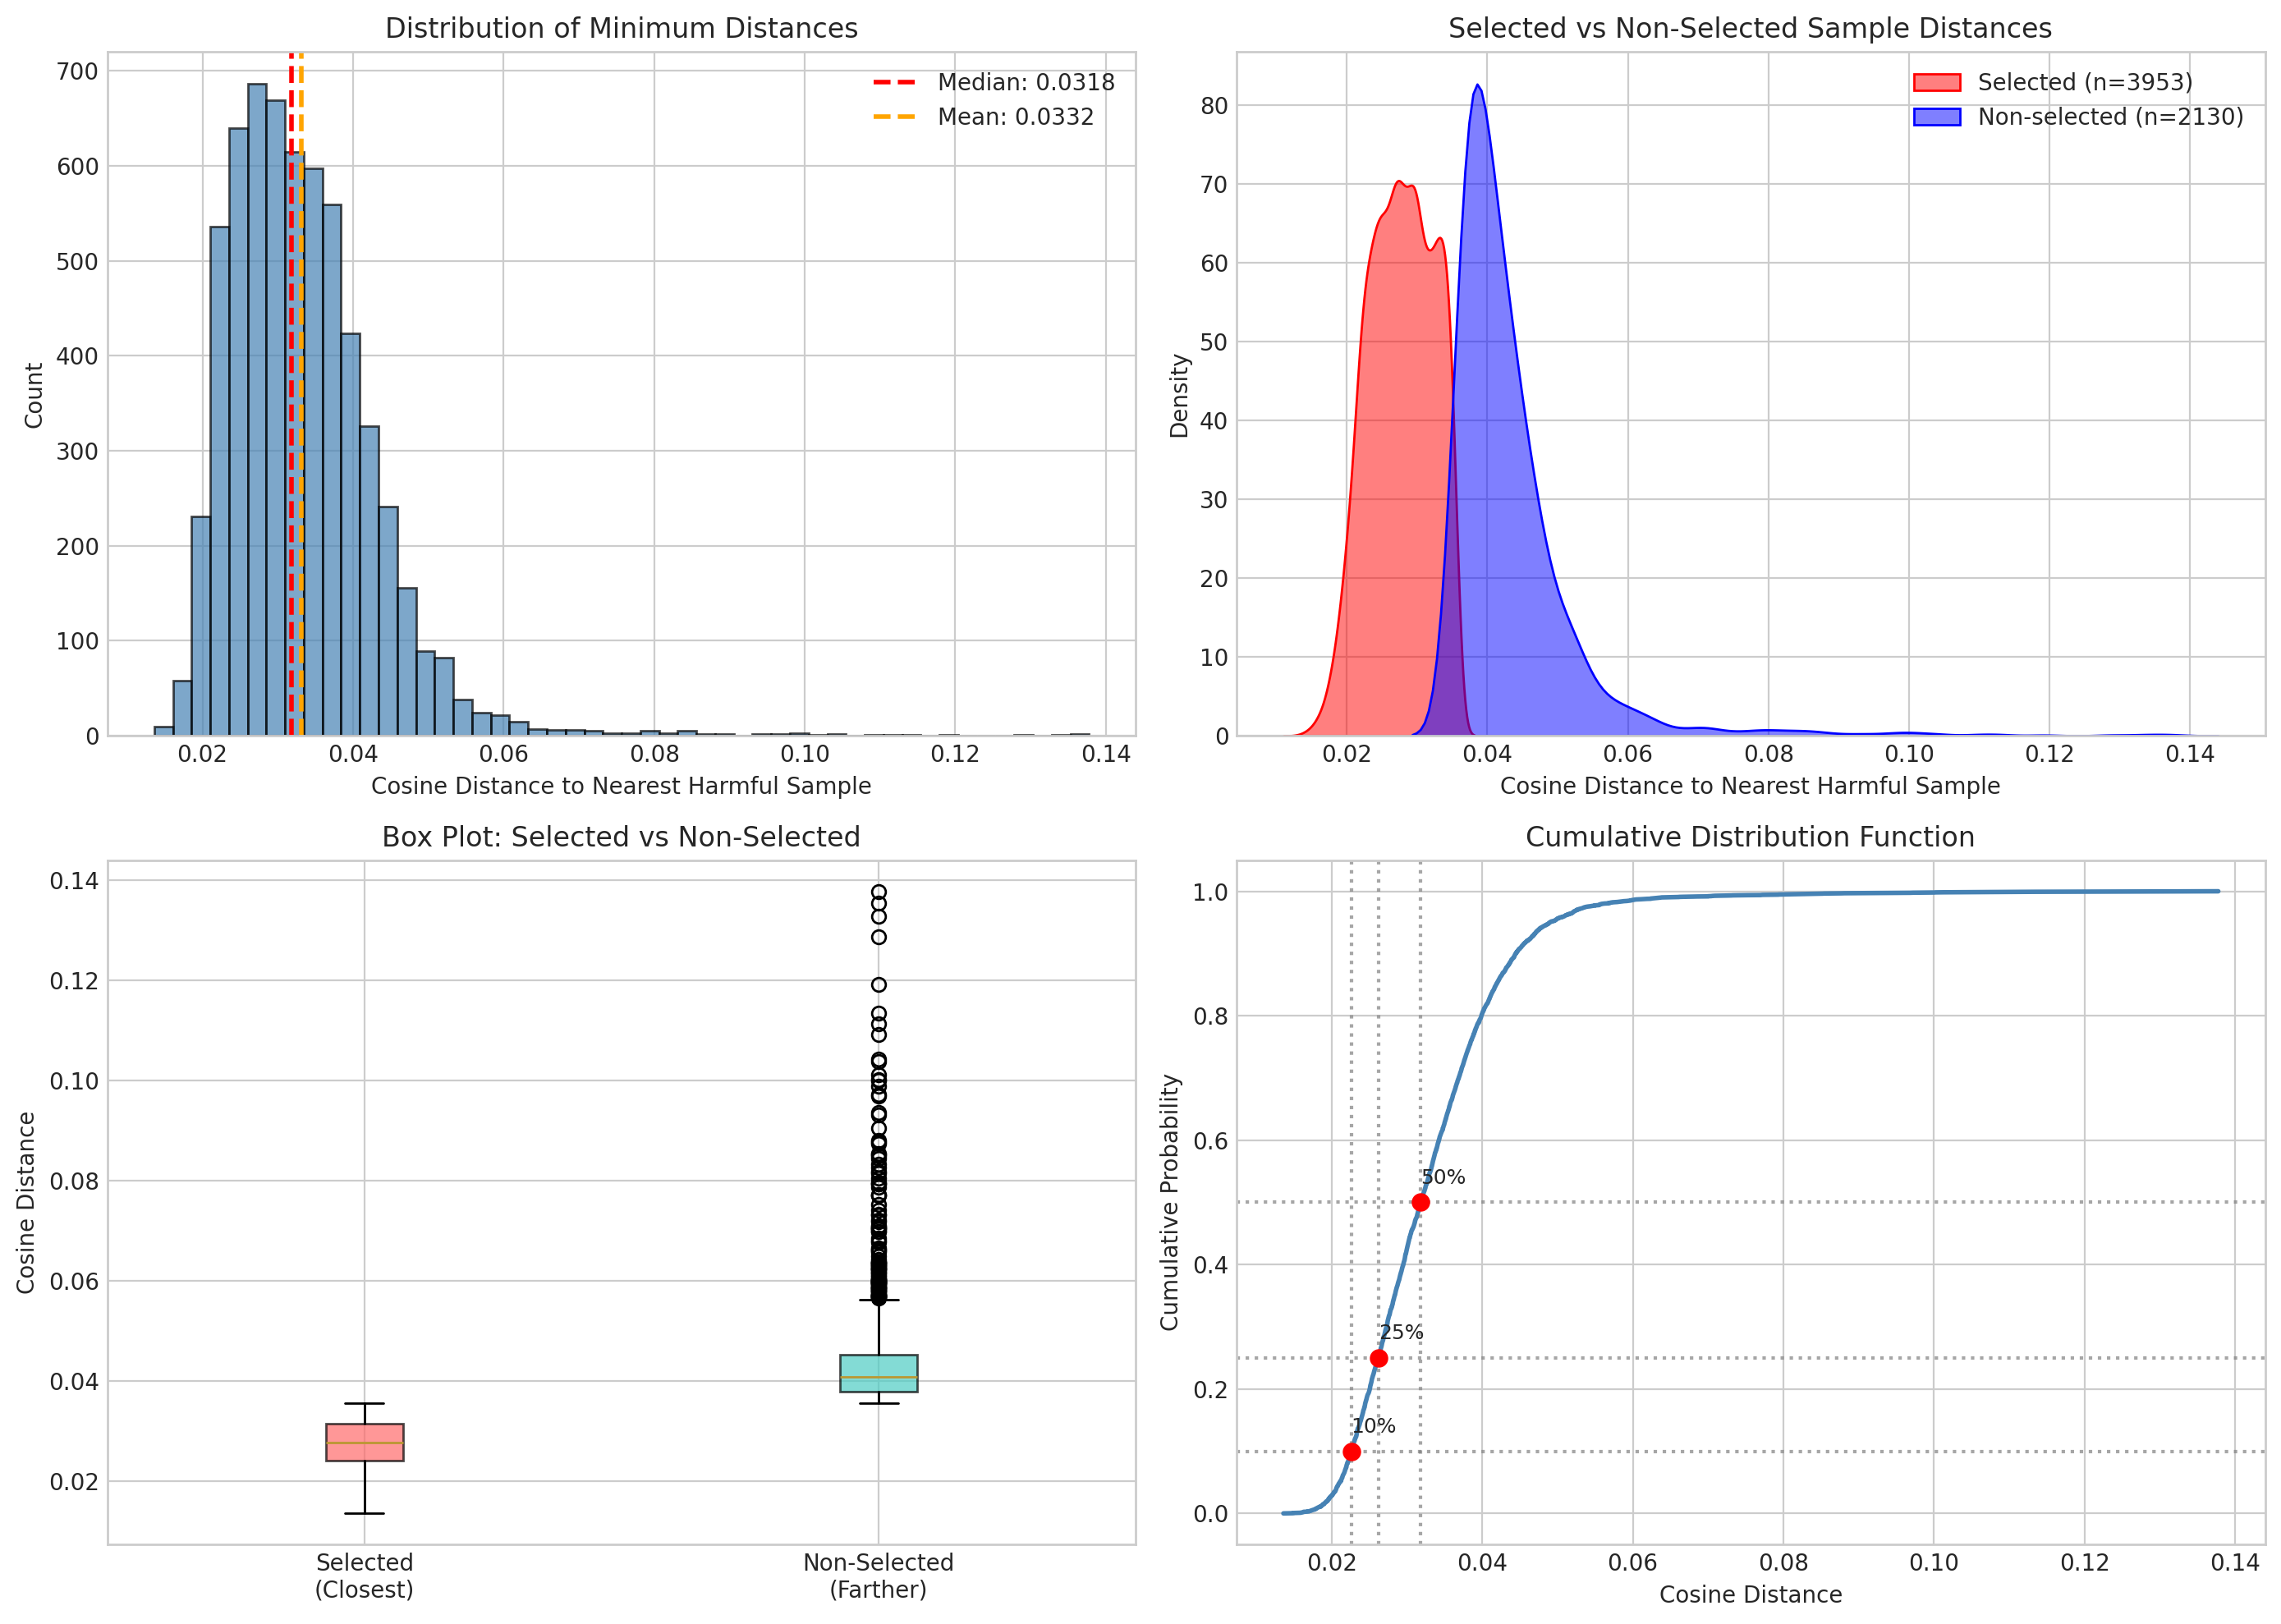

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of minimum distances
ax = axes[0, 0]
ax.hist(min_distances, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(np.median(min_distances), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(min_distances):.4f}')
ax.axvline(min_distances.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {min_distances.mean():.4f}')
ax.set_xlabel('Cosine Distance to Nearest Harmful Sample')
ax.set_ylabel('Count')
ax.set_title('Distribution of Minimum Distances')
ax.legend()

# 2. KDE plot comparing selected vs non-selected
ax = axes[0, 1]
sns.kdeplot(selected_distances, ax=ax, label=f'Selected (n={len(selected_distances)})', fill=True, alpha=0.5, color='red')
sns.kdeplot(non_selected_distances, ax=ax, label=f'Non-selected (n={len(non_selected_distances)})', fill=True, alpha=0.5, color='blue')
ax.set_xlabel('Cosine Distance to Nearest Harmful Sample')
ax.set_ylabel('Density')
ax.set_title('Selected vs Non-Selected Sample Distances')
ax.legend()

# 3. Box plot comparison
ax = axes[1, 0]
box_data = [selected_distances, non_selected_distances]
bp = ax.boxplot(box_data, labels=['Selected\n(Closest)', 'Non-Selected\n(Farther)'], patch_artist=True)
colors = ['#ff6b6b', '#4ecdc4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Cosine Distance')
ax.set_title('Box Plot: Selected vs Non-Selected')

# 4. Cumulative distribution
ax = axes[1, 1]
sorted_distances = np.sort(min_distances)
cdf = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
ax.plot(sorted_distances, cdf, linewidth=2, color='steelblue')
# Mark some percentiles
for p in [10, 25, 50]:
    val = np.percentile(min_distances, p)
    ax.axvline(val, color='gray', linestyle=':', alpha=0.7)
    ax.axhline(p/100, color='gray', linestyle=':', alpha=0.7)
    ax.scatter([val], [p/100], color='red', s=50, zorder=5)
    ax.annotate(f'{p}%', (val, p/100 + 0.03), fontsize=9)
ax.set_xlabel('Cosine Distance')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Cumulative Distribution Function')

plt.tight_layout()
plt.savefig('figures/distance_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Create figures directory if it doesn't exist
import os
os.makedirs('figures', exist_ok=True)

## 4. Embedding Space Visualization with t-SNE

In [8]:
from sklearn.manifold import TSNE

# Combine embeddings for visualization
all_embeddings = np.vstack([voicebench_embeddings, advbench_embeddings])
print(f"Combined embeddings shape: {all_embeddings.shape}")

# Create labels
n_vb = len(voicebench_embeddings)
n_ab = len(advbench_embeddings)

# Labels: 0 = non-selected benign, 1 = selected benign, 2 = harmful
labels = np.zeros(len(all_embeddings), dtype=int)
labels[filtered_indices] = 1  # Selected benign
labels[n_vb:] = 2  # Harmful

Combined embeddings shape: (6603, 3584)


In [9]:
# Run t-SNE (this may take a while)
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, verbose=1)
embeddings_2d = tsne.fit_transform(all_embeddings)
print("t-SNE completed!")

Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6603 samples in 0.011s...
[t-SNE] Computed neighbors for 6603 samples in 2.353s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6603
[t-SNE] Computed conditional probabilities for sample 2000 / 6603
[t-SNE] Computed conditional probabilities for sample 3000 / 6603
[t-SNE] Computed conditional probabilities for sample 4000 / 6603
[t-SNE] Computed conditional probabilities for sample 5000 / 6603
[t-SNE] Computed conditional probabilities for sample 6000 / 6603
[t-SNE] Computed conditional probabilities for sample 6603 / 6603
[t-SNE] Mean sigma: 5.458430
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.475319
[t-SNE] KL divergence after 1000 iterations: 1.385195
t-SNE completed!


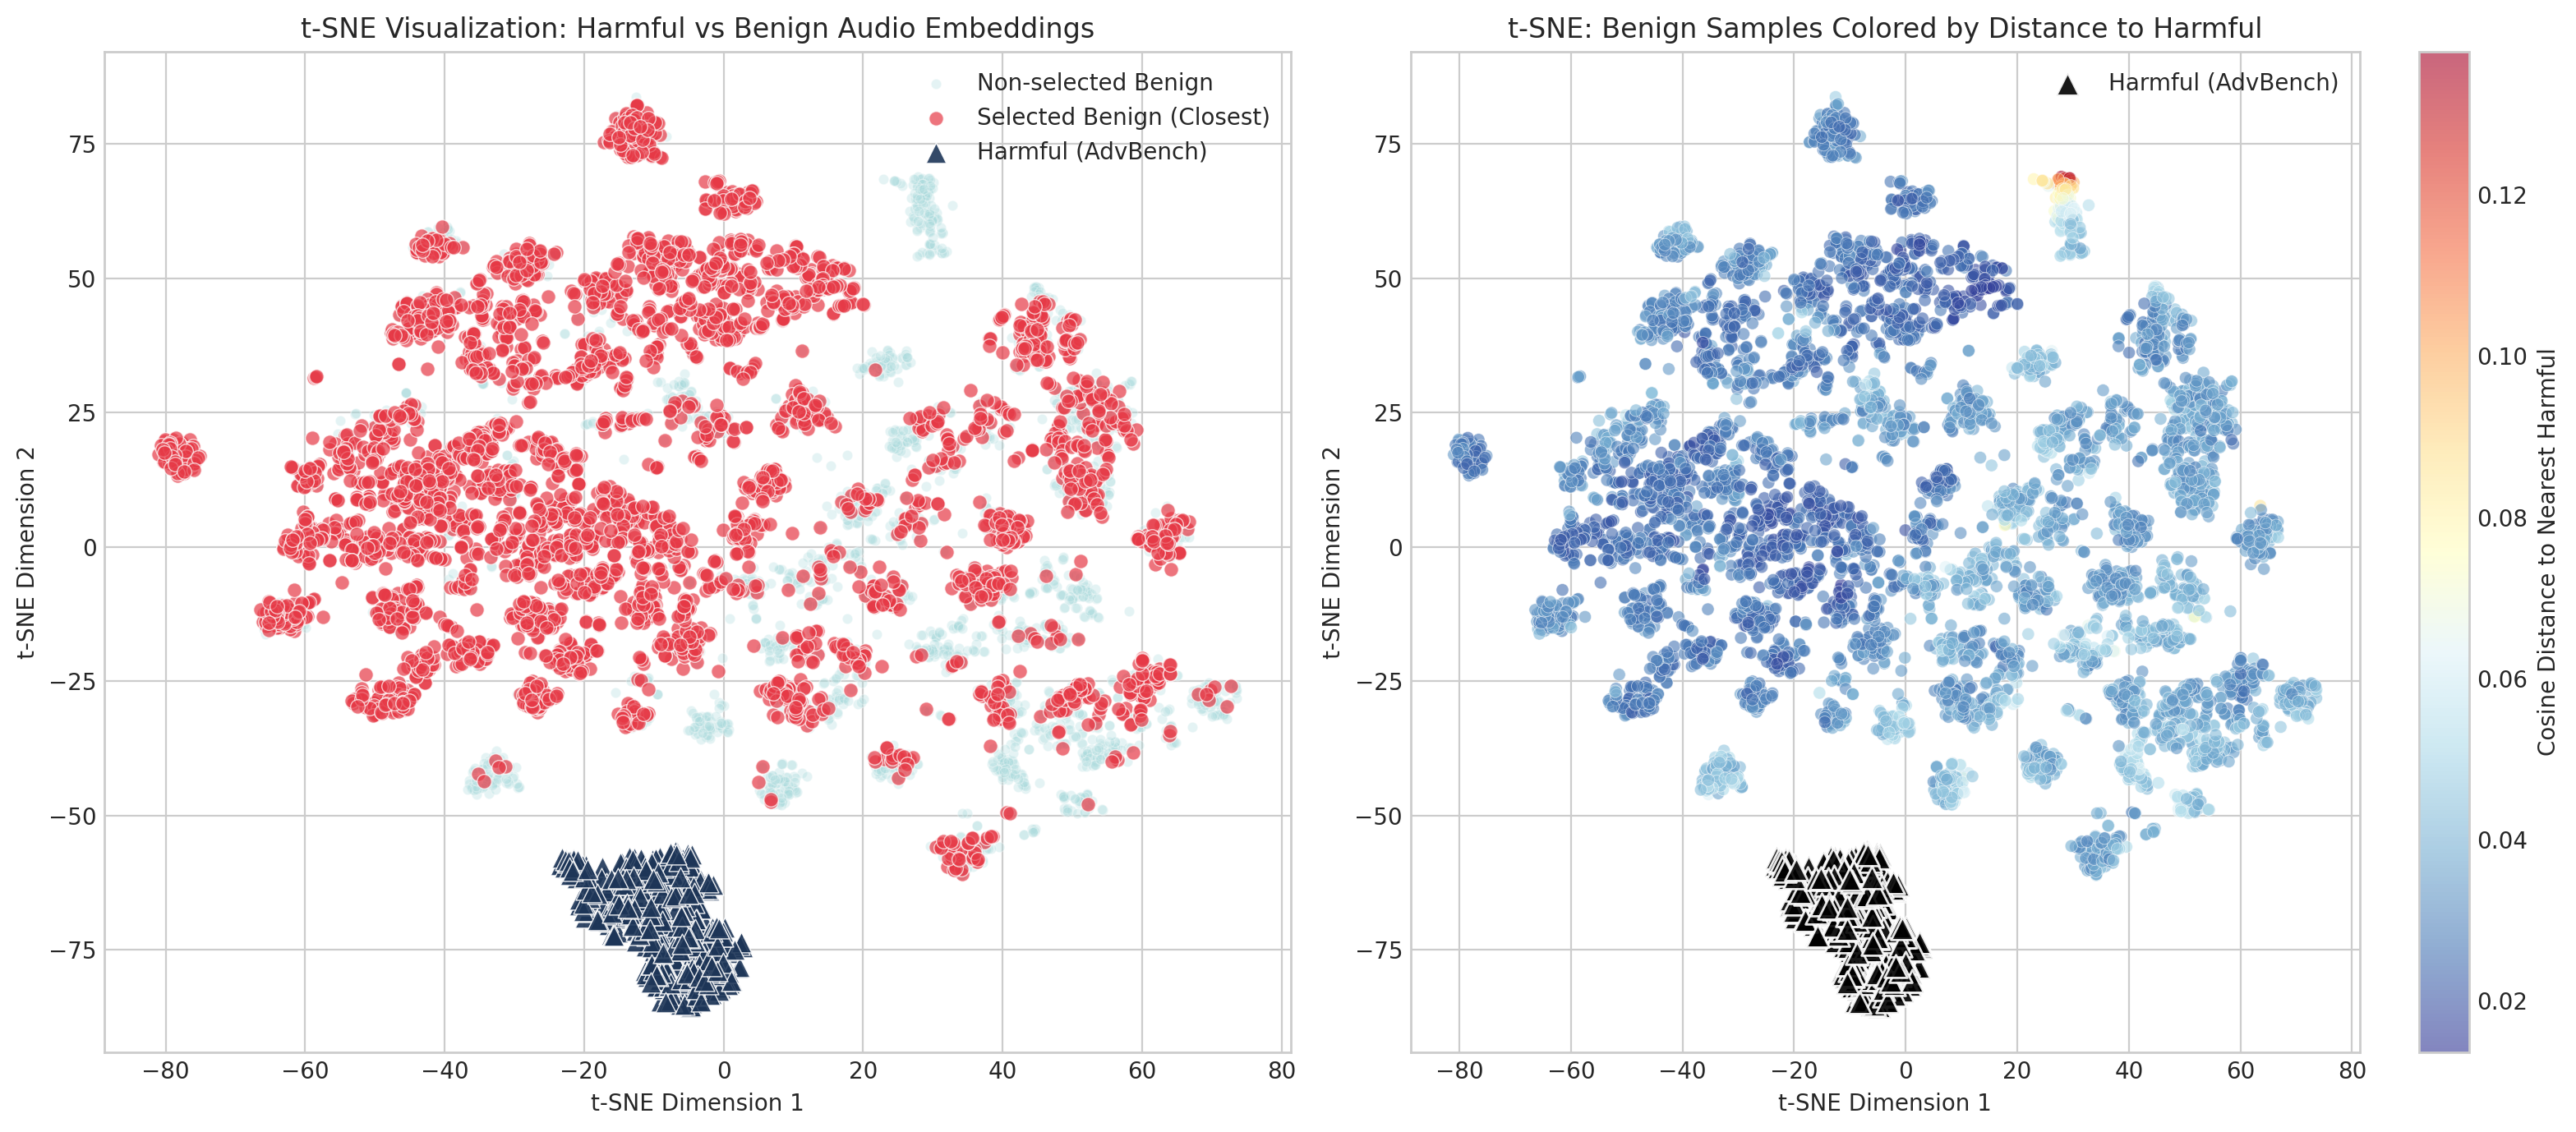

In [10]:
# Plot t-SNE results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Three categories
ax = axes[0]
colors = ['#a8dadc', '#e63946', '#1d3557']  # light blue, red, dark blue
labels_names = ['Non-selected Benign', 'Selected Benign (Closest)', 'Harmful (AdvBench)']
markers = ['o', 'o', '^']
sizes = [20, 40, 80]
alphas = [0.3, 0.7, 0.9]

for i, (label_name, color, marker, size, alpha) in enumerate(zip(labels_names, colors, markers, sizes, alphas)):
    mask = labels == i
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
               c=color, label=label_name, s=size, alpha=alpha, marker=marker, edgecolors='white', linewidth=0.5)

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('t-SNE Visualization: Harmful vs Benign Audio Embeddings')
ax.legend(loc='best', fontsize=10)

# Plot 2: Color by distance
ax = axes[1]
# Only plot VoiceBench samples, colored by distance
vb_embeddings_2d = embeddings_2d[:n_vb]
ab_embeddings_2d = embeddings_2d[n_vb:]

scatter = ax.scatter(vb_embeddings_2d[:, 0], vb_embeddings_2d[:, 1], 
                     c=min_distances, cmap='RdYlBu_r', s=30, alpha=0.6, edgecolors='white', linewidth=0.3)
ax.scatter(ab_embeddings_2d[:, 0], ab_embeddings_2d[:, 1], 
           c='black', marker='^', s=100, label='Harmful (AdvBench)', alpha=0.9, edgecolors='white', linewidth=1)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cosine Distance to Nearest Harmful')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('t-SNE: Benign Samples Colored by Distance to Harmful')
ax.legend(loc='best')

plt.tight_layout()
plt.savefig('figures/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. UMAP Visualization (Alternative to t-SNE)

In [11]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    print("UMAP not installed. Install with: pip install umap-learn")
    HAS_UMAP = False

UMAP not installed. Install with: pip install umap-learn


In [12]:
if HAS_UMAP:
    print("Running UMAP...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, verbose=True)
    embeddings_umap = reducer.fit_transform(all_embeddings)
    print("UMAP completed!")

In [13]:
if HAS_UMAP:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Plot 1: Three categories
    ax = axes[0]
    colors = ['#a8dadc', '#e63946', '#1d3557']
    labels_names = ['Non-selected Benign', 'Selected Benign (Closest)', 'Harmful (AdvBench)']
    markers = ['o', 'o', '^']
    sizes = [20, 40, 80]
    alphas = [0.3, 0.7, 0.9]

    for i, (label_name, color, marker, size, alpha) in enumerate(zip(labels_names, colors, markers, sizes, alphas)):
        mask = labels == i
        ax.scatter(embeddings_umap[mask, 0], embeddings_umap[mask, 1], 
                   c=color, label=label_name, s=size, alpha=alpha, marker=marker, edgecolors='white', linewidth=0.5)

    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title('UMAP Visualization: Harmful vs Benign Audio Embeddings')
    ax.legend(loc='best', fontsize=10)

    # Plot 2: Color by distance
    ax = axes[1]
    vb_umap = embeddings_umap[:n_vb]
    ab_umap = embeddings_umap[n_vb:]

    scatter = ax.scatter(vb_umap[:, 0], vb_umap[:, 1], 
                         c=min_distances, cmap='RdYlBu_r', s=30, alpha=0.6, edgecolors='white', linewidth=0.3)
    ax.scatter(ab_umap[:, 0], ab_umap[:, 1], 
               c='black', marker='^', s=100, label='Harmful (AdvBench)', alpha=0.9, edgecolors='white', linewidth=1)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Cosine Distance to Nearest Harmful')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title('UMAP: Benign Samples Colored by Distance to Harmful')
    ax.legend(loc='best')

    plt.tight_layout()
    plt.savefig('figures/umap_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Distance Heatmap (Sample of Distance Matrix)

In [14]:
# Create a heatmap of distances (sample for visibility)
# Sample benign indices: mix of selected and non-selected
n_sample_benign = 50
n_sample_harmful = min(50, len(advbench_embeddings))

# Get indices sorted by distance
sorted_indices = np.argsort(min_distances)

# Sample from different parts of the distribution
sample_benign_indices = np.concatenate([
    sorted_indices[:n_sample_benign//2],  # Closest
    sorted_indices[-n_sample_benign//2:]  # Farthest
])

sample_harmful_indices = np.linspace(0, len(advbench_embeddings)-1, n_sample_harmful, dtype=int)

# Extract subset of distance matrix
distance_subset = all_distances[sample_benign_indices][:, sample_harmful_indices]

print(f"Distance subset shape: {distance_subset.shape}")

Distance subset shape: (50, 50)


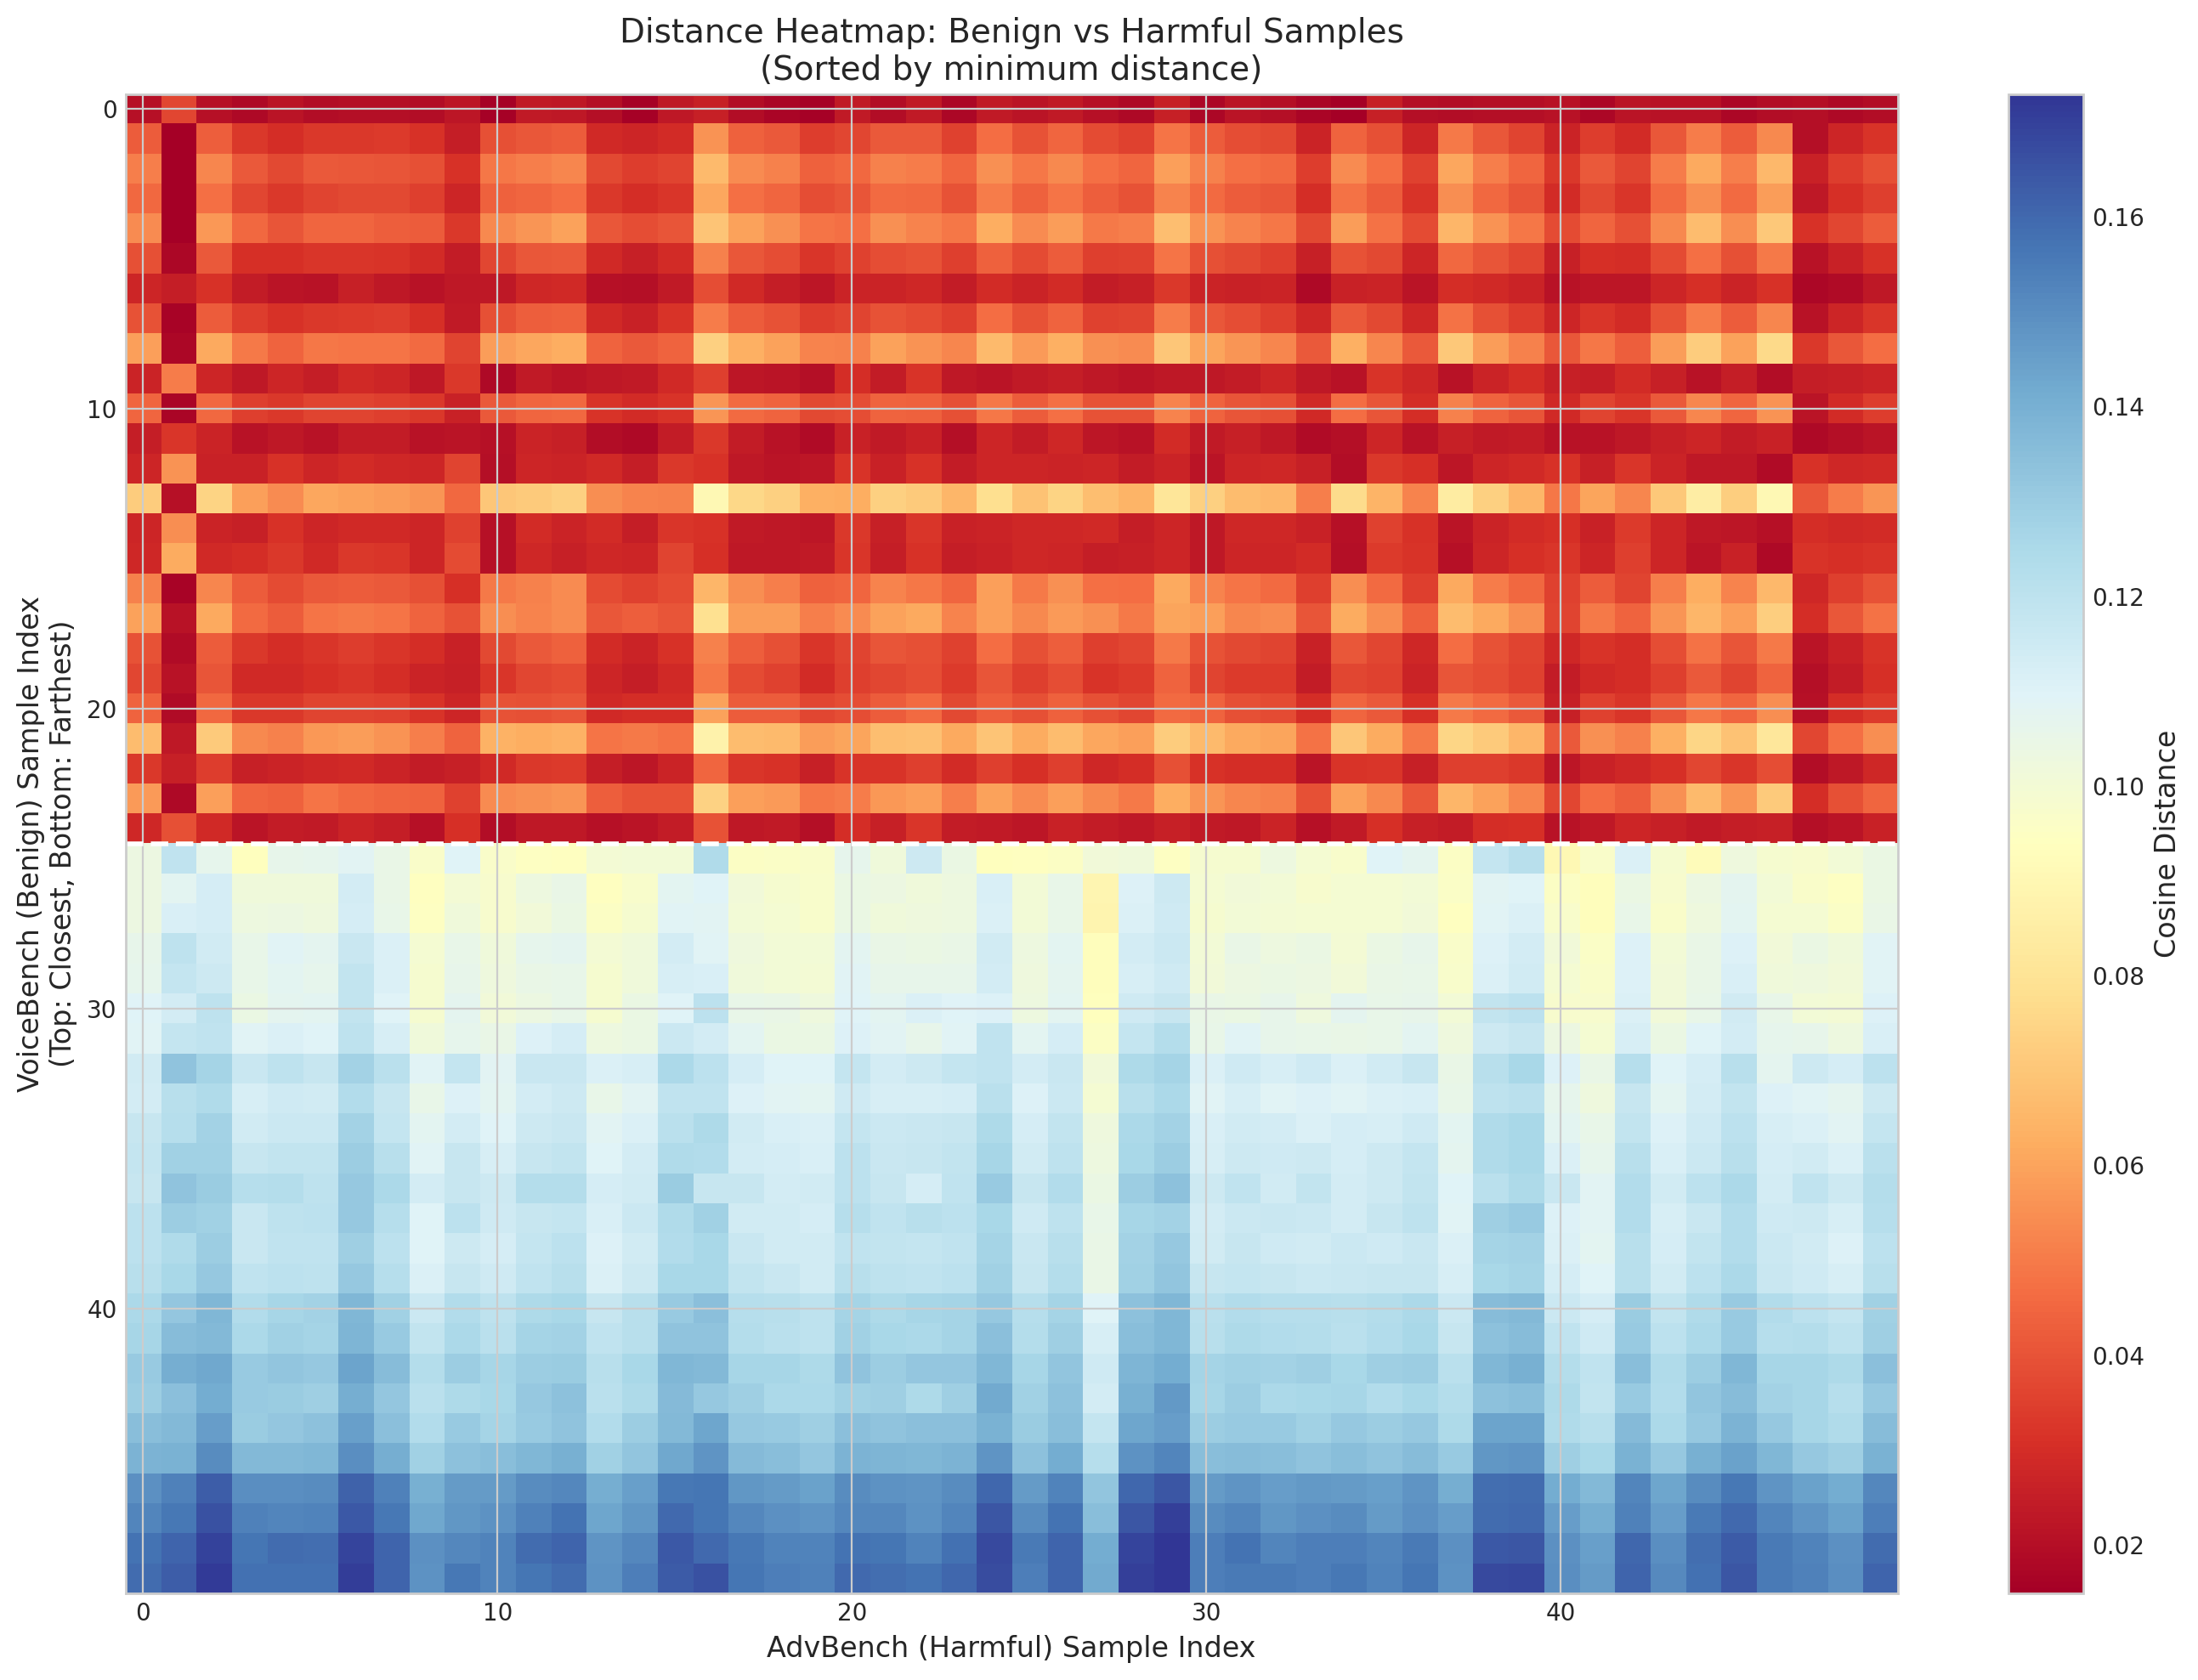

In [15]:
fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(distance_subset, aspect='auto', cmap='RdYlBu')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Distance', fontsize=12)

ax.set_xlabel('AdvBench (Harmful) Sample Index', fontsize=12)
ax.set_ylabel('VoiceBench (Benign) Sample Index\n(Top: Closest, Bottom: Farthest)', fontsize=12)
ax.set_title('Distance Heatmap: Benign vs Harmful Samples\n(Sorted by minimum distance)', fontsize=14)

# Add horizontal line to separate closest and farthest
ax.axhline(n_sample_benign//2 - 0.5, color='white', linewidth=2, linestyle='--')

plt.tight_layout()
plt.savefig('figures/distance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Nearest Neighbor Analysis

In [16]:
# Find which harmful samples are most often the nearest neighbor
nearest_harmful_idx = np.argmin(all_distances, axis=1)

# Count how many times each harmful sample is the nearest neighbor
unique, counts = np.unique(nearest_harmful_idx, return_counts=True)
nn_counts = dict(zip(unique, counts))

# Sort by count
sorted_harmful = sorted(nn_counts.items(), key=lambda x: x[1], reverse=True)

print("Top 20 most frequently matched harmful samples:")
print("="*50)
for idx, count in sorted_harmful[:20]:
    pct = count / len(min_distances) * 100
    if advbench_files is not None:
        filename = Path(advbench_files[idx]).name
        print(f"  Harmful #{idx:3d} ({filename}): {count:4d} matches ({pct:.1f}%)")
    else:
        print(f"  Harmful #{idx:3d}: {count:4d} matches ({pct:.1f}%)")

Top 20 most frequently matched harmful samples:
  Harmful #358 (advbench_00358.mp3): 1146 matches (18.8%)
  Harmful #170 (advbench_00170.mp3):  820 matches (13.5%)
  Harmful # 90 (advbench_00090.mp3):  449 matches (7.4%)
  Harmful # 36 (advbench_00036.mp3):  423 matches (7.0%)
  Harmful # 55 (advbench_00055.mp3):  421 matches (6.9%)
  Harmful # 94 (advbench_00094.mp3):  295 matches (4.8%)
  Harmful #101 (advbench_00101.mp3):  205 matches (3.4%)
  Harmful #509 (advbench_00509.mp3):  202 matches (3.3%)
  Harmful # 79 (advbench_00079.mp3):  199 matches (3.3%)
  Harmful #192 (advbench_00192.mp3):  132 matches (2.2%)
  Harmful #236 (advbench_00236.mp3):  132 matches (2.2%)
  Harmful #456 (advbench_00456.mp3):  124 matches (2.0%)
  Harmful #324 (advbench_00324.mp3):  123 matches (2.0%)
  Harmful #399 (advbench_00399.mp3):  111 matches (1.8%)
  Harmful #325 (advbench_00325.mp3):   93 matches (1.5%)
  Harmful #443 (advbench_00443.mp3):   91 matches (1.5%)
  Harmful #210 (advbench_00210.mp3):  

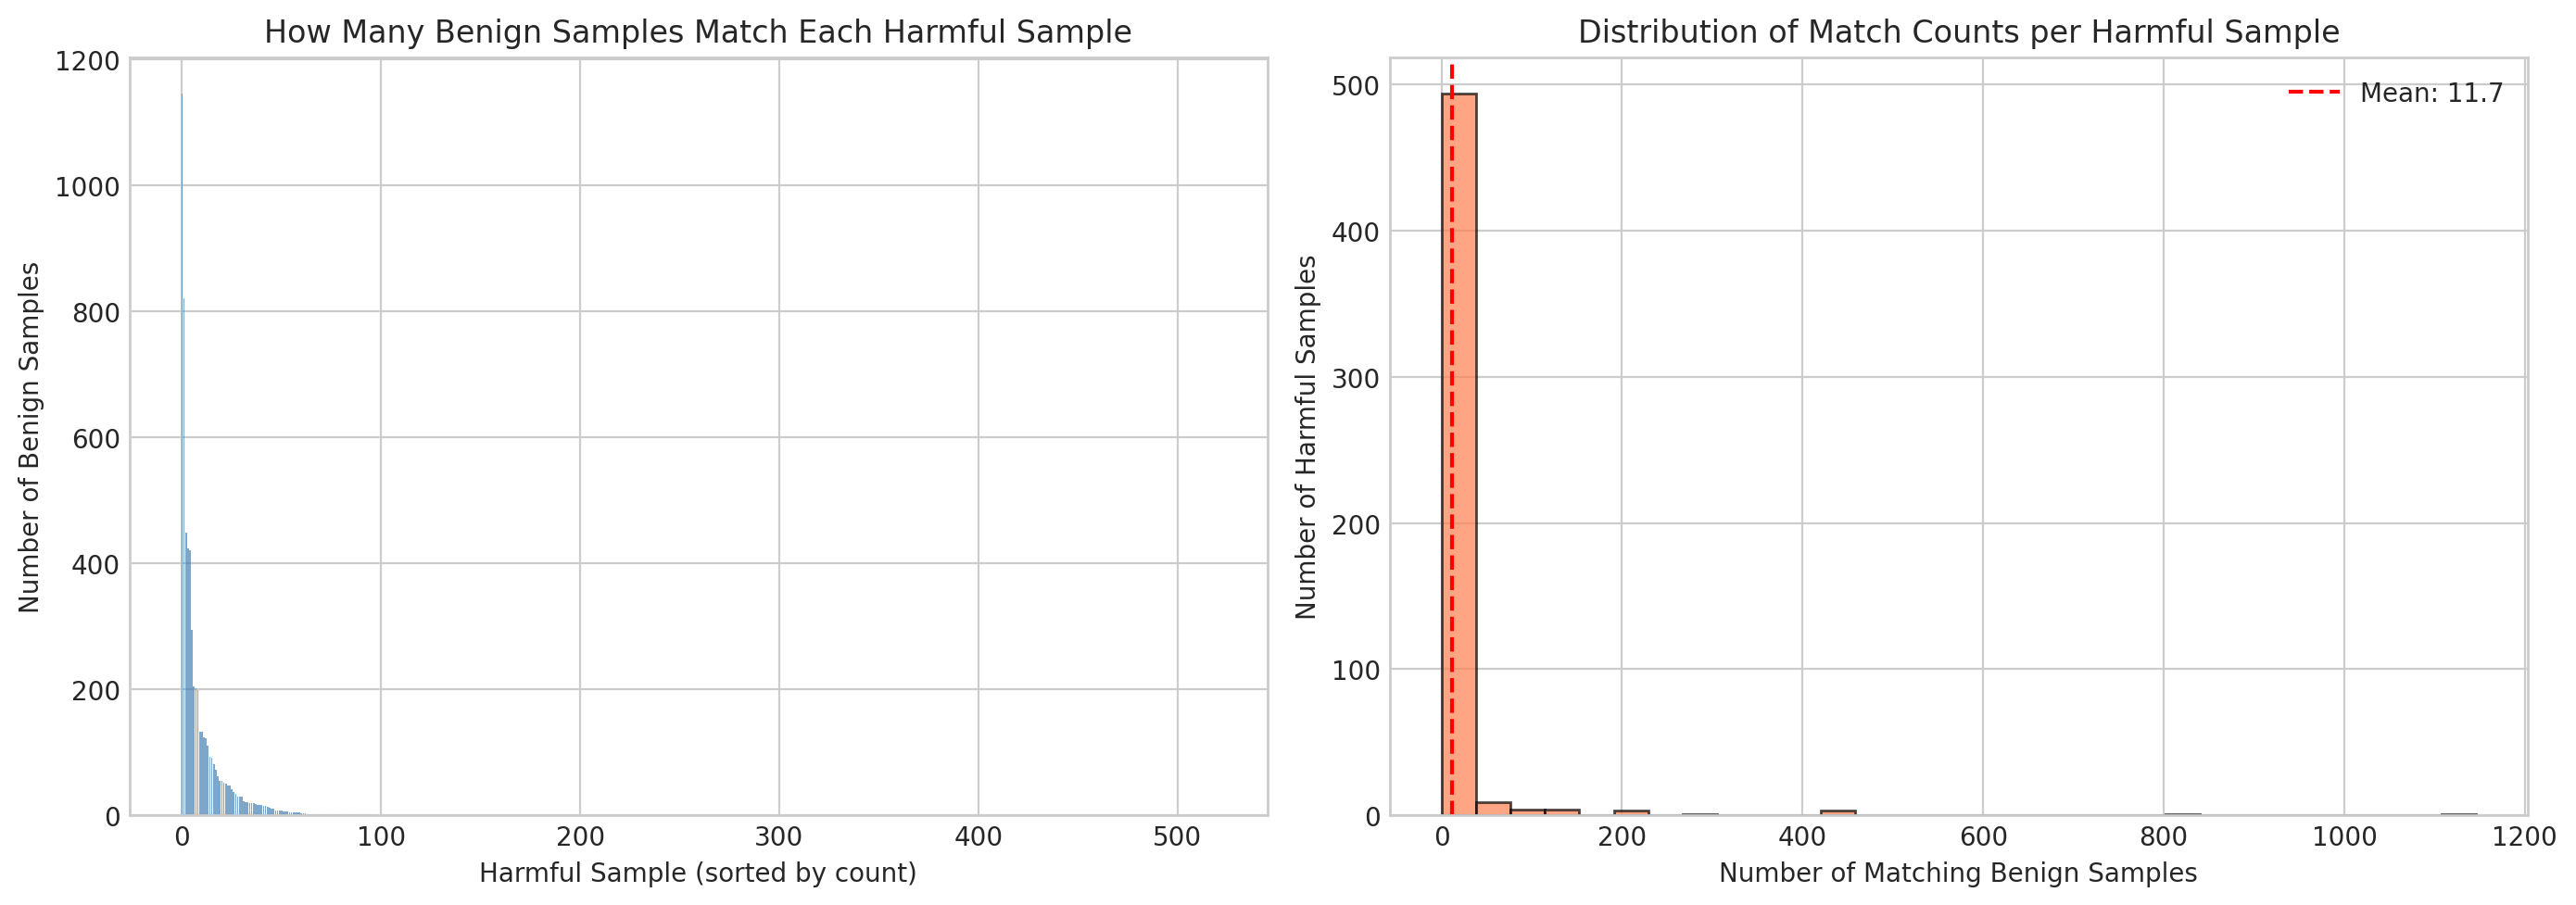

In [17]:
# Plot distribution of nearest neighbor counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All harmful samples' match counts
all_counts = [nn_counts.get(i, 0) for i in range(len(advbench_embeddings))]

ax = axes[0]
ax.bar(range(len(all_counts)), sorted(all_counts, reverse=True), color='steelblue', alpha=0.7)
ax.set_xlabel('Harmful Sample (sorted by count)')
ax.set_ylabel('Number of Benign Samples')
ax.set_title('How Many Benign Samples Match Each Harmful Sample')

ax = axes[1]
ax.hist(all_counts, bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Number of Matching Benign Samples')
ax.set_ylabel('Number of Harmful Samples')
ax.set_title('Distribution of Match Counts per Harmful Sample')
ax.axvline(np.mean(all_counts), color='red', linestyle='--', label=f'Mean: {np.mean(all_counts):.1f}')
ax.legend()

plt.tight_layout()
plt.savefig('figures/nearest_neighbor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. PCA Analysis

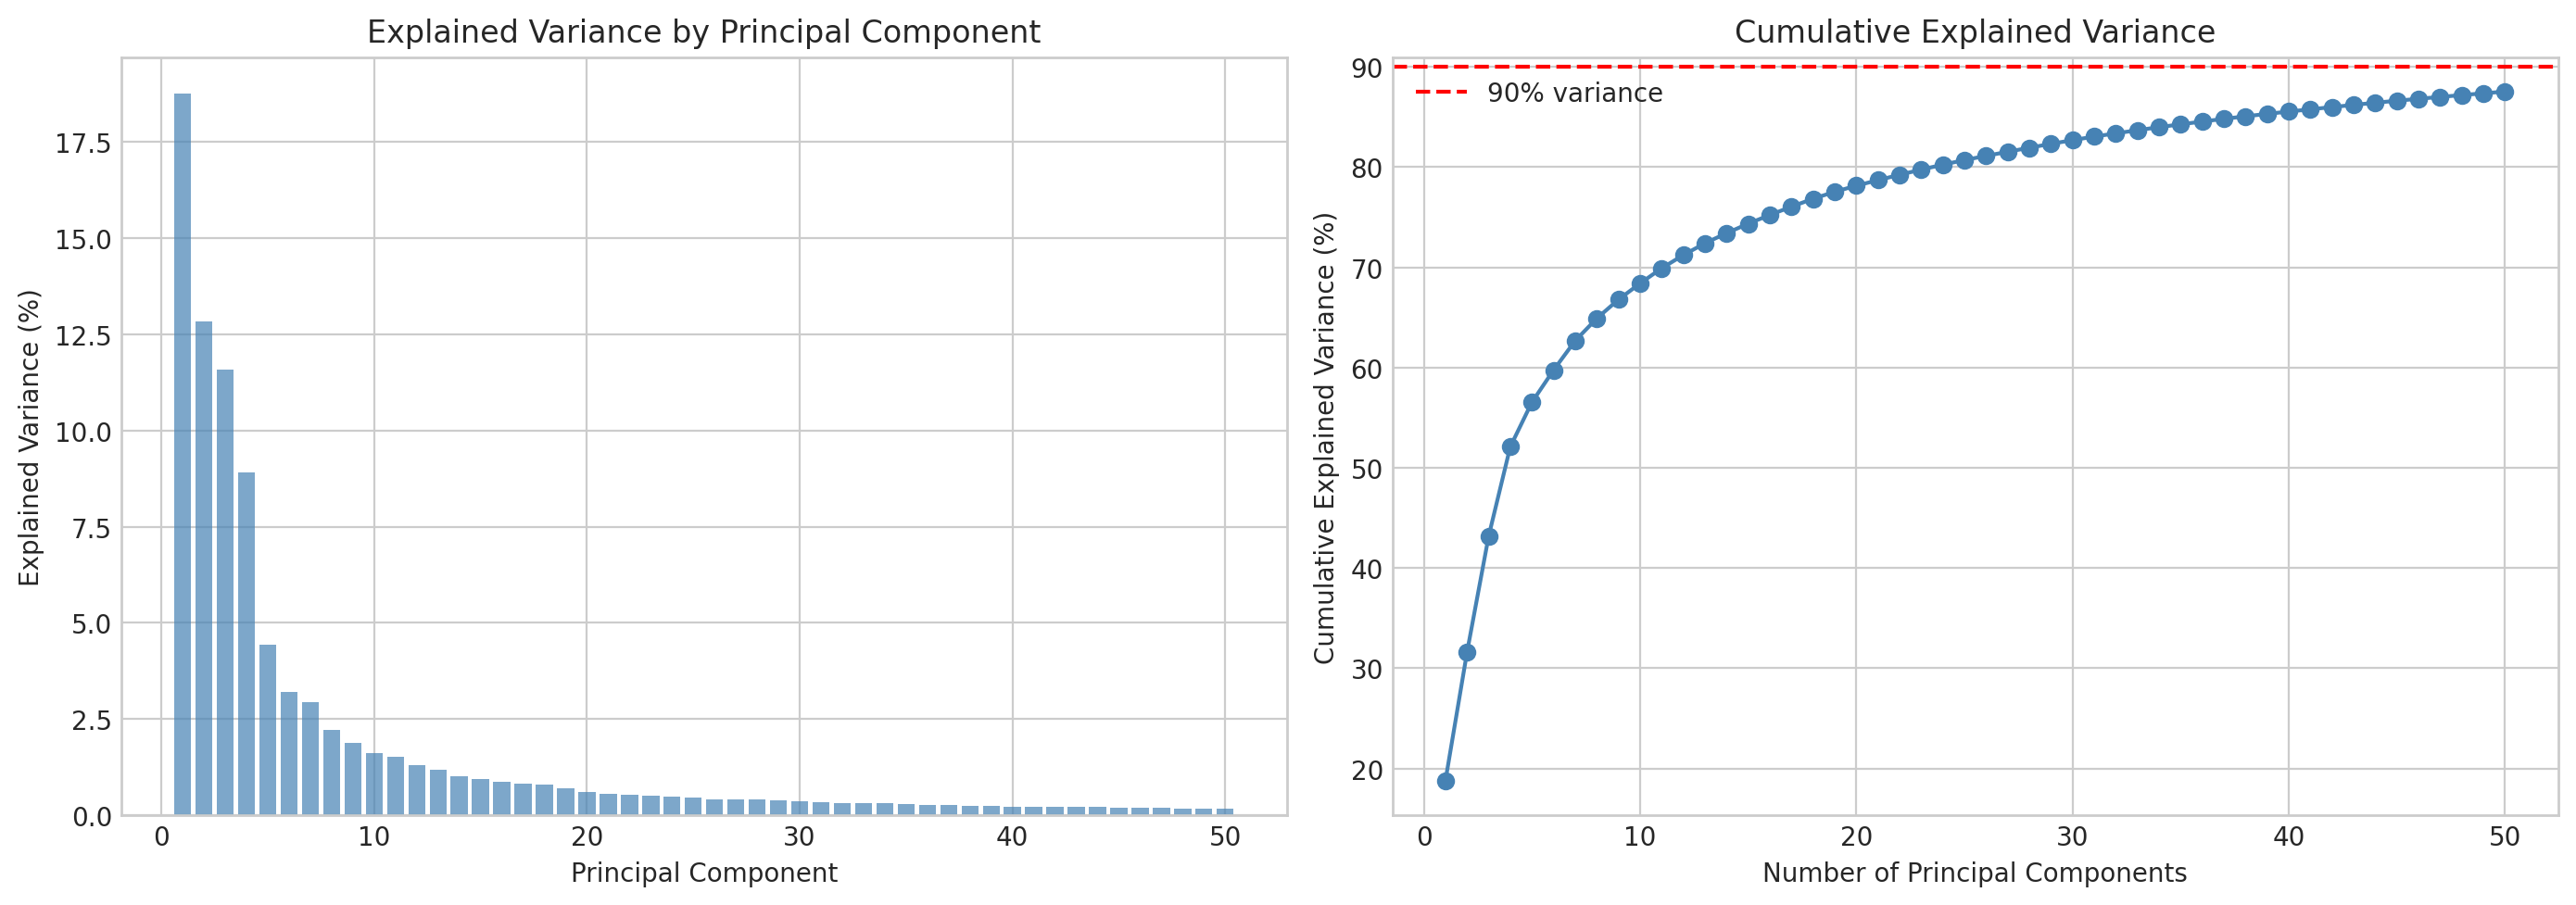

Number of components for 90% variance: 1
Number of components for 95% variance: 1


In [18]:
from sklearn.decomposition import PCA

# Run PCA
pca = PCA(n_components=50)
pca.fit(all_embeddings)

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, 51), pca.explained_variance_ratio_ * 100, color='steelblue', alpha=0.7)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Explained Variance by Principal Component')

ax = axes[1]
cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(range(1, 51), cumulative_var, 'o-', color='steelblue')
ax.axhline(90, color='red', linestyle='--', label='90% variance')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance')
ax.legend()

plt.tight_layout()
plt.savefig('figures/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Number of components for 90% variance: {np.argmax(cumulative_var >= 90) + 1}")
print(f"Number of components for 95% variance: {np.argmax(cumulative_var >= 95) + 1}")

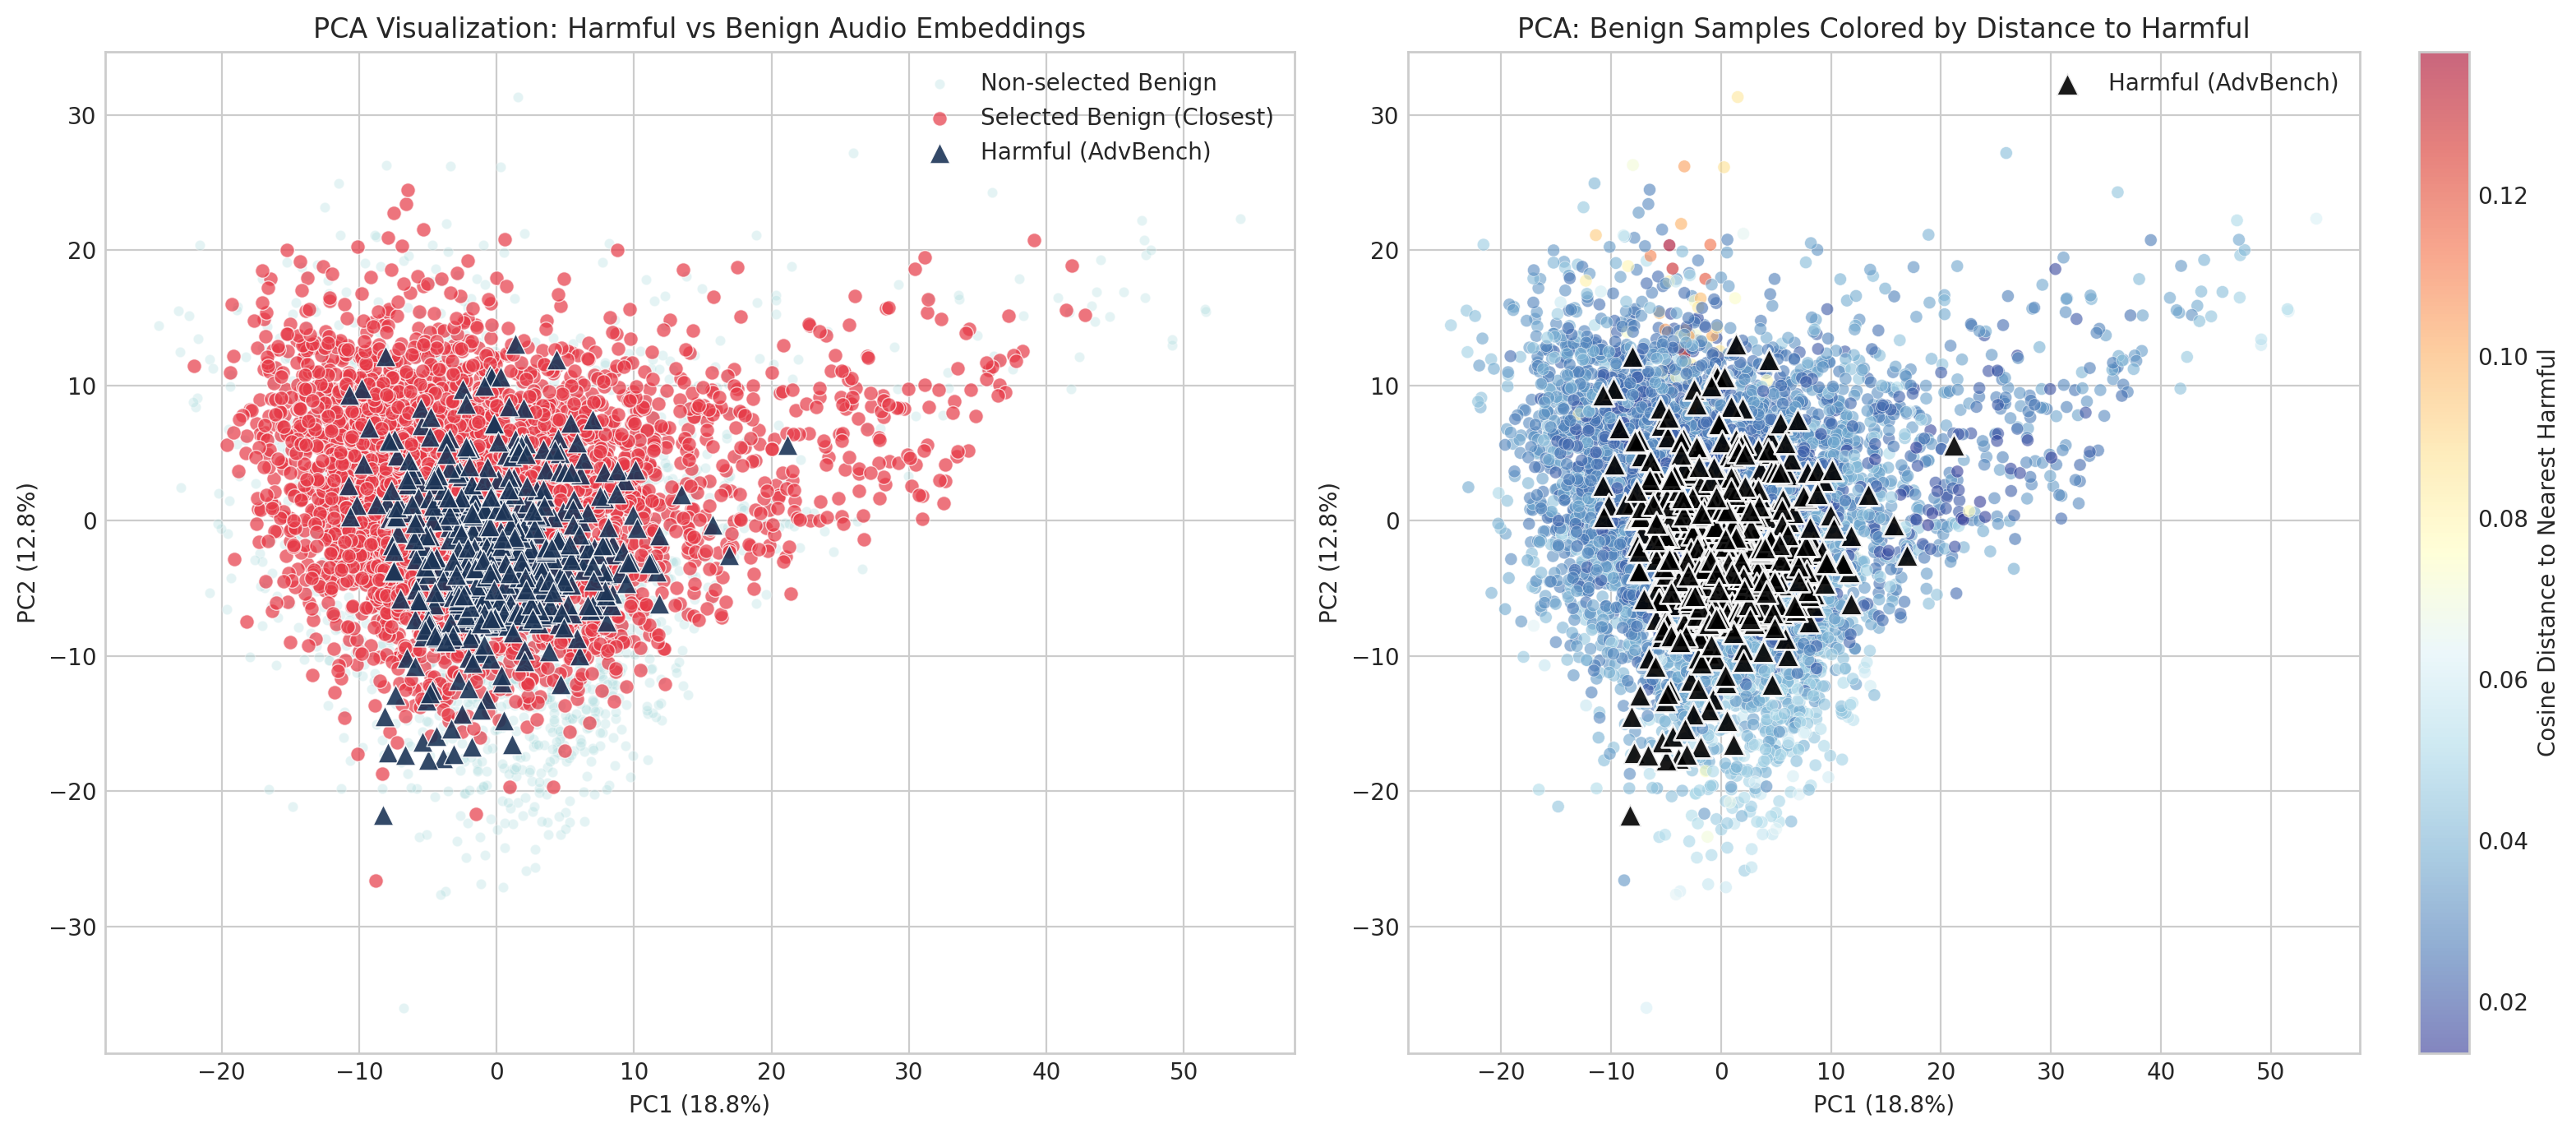

In [19]:
# PCA 2D visualization
pca_2d = PCA(n_components=2)
embeddings_pca = pca_2d.fit_transform(all_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Three categories
ax = axes[0]
colors = ['#a8dadc', '#e63946', '#1d3557']
labels_names = ['Non-selected Benign', 'Selected Benign (Closest)', 'Harmful (AdvBench)']
markers = ['o', 'o', '^']
sizes = [20, 40, 80]
alphas = [0.3, 0.7, 0.9]

for i, (label_name, color, marker, size, alpha) in enumerate(zip(labels_names, colors, markers, sizes, alphas)):
    mask = labels == i
    ax.scatter(embeddings_pca[mask, 0], embeddings_pca[mask, 1], 
               c=color, label=label_name, s=size, alpha=alpha, marker=marker, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Visualization: Harmful vs Benign Audio Embeddings')
ax.legend(loc='best', fontsize=10)

# Plot 2: Color by distance
ax = axes[1]
vb_pca = embeddings_pca[:n_vb]
ab_pca = embeddings_pca[n_vb:]

scatter = ax.scatter(vb_pca[:, 0], vb_pca[:, 1], 
                     c=min_distances, cmap='RdYlBu_r', s=30, alpha=0.6, edgecolors='white', linewidth=0.3)
ax.scatter(ab_pca[:, 0], ab_pca[:, 1], 
           c='black', marker='^', s=100, label='Harmful (AdvBench)', alpha=0.9, edgecolors='white', linewidth=1)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cosine Distance to Nearest Harmful')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA: Benign Samples Colored by Distance to Harmful')
ax.legend(loc='best')

plt.tight_layout()
plt.savefig('figures/pca_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Distance Threshold Analysis

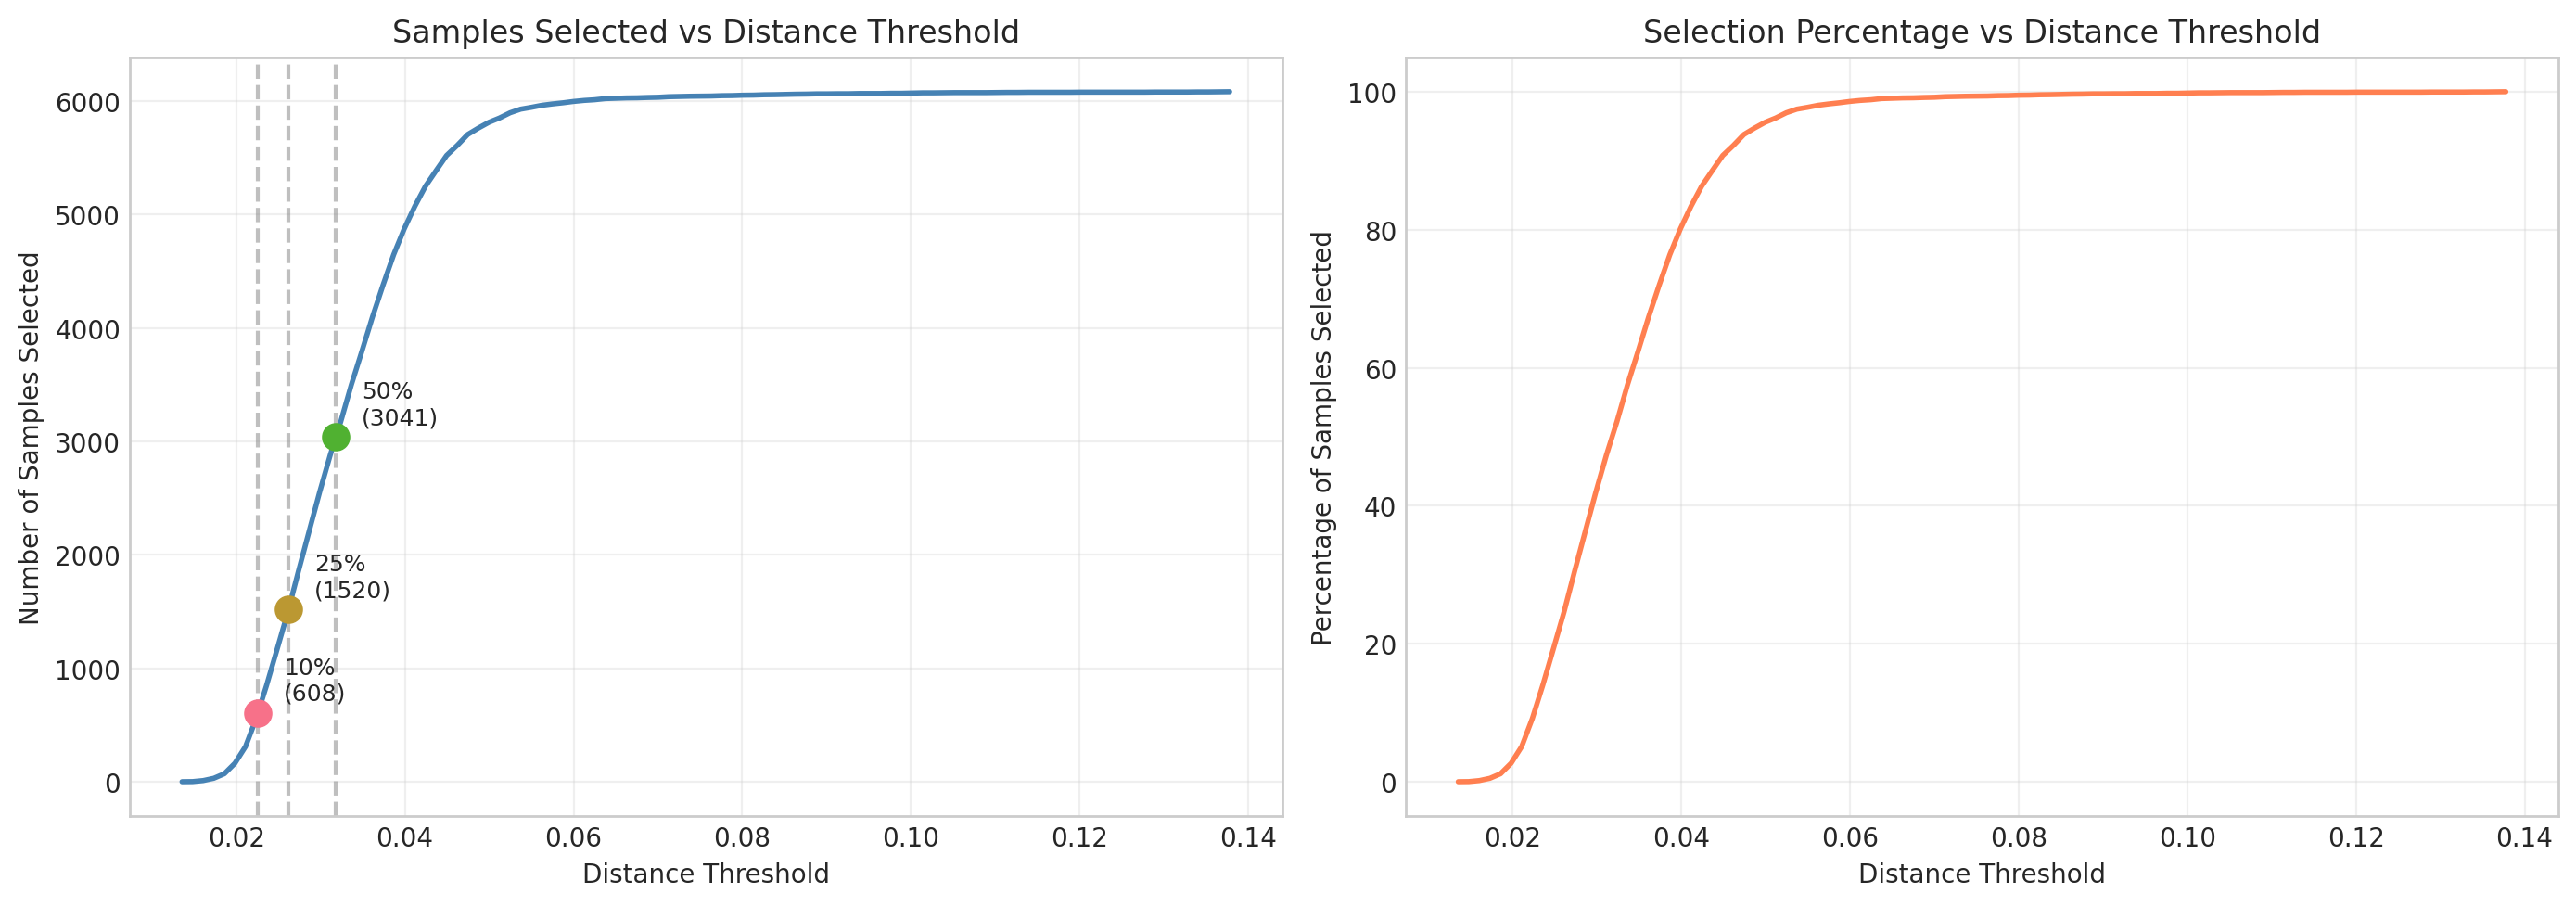

In [20]:
# Analyze how many samples are selected at different thresholds
thresholds = np.linspace(min_distances.min(), min_distances.max(), 100)
samples_below_threshold = [(min_distances <= t).sum() for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresholds, samples_below_threshold, linewidth=2, color='steelblue')
ax.set_xlabel('Distance Threshold')
ax.set_ylabel('Number of Samples Selected')
ax.set_title('Samples Selected vs Distance Threshold')
ax.grid(True, alpha=0.3)

# Mark common percentages
for pct in [10, 25, 50]:
    threshold = np.percentile(min_distances, pct)
    n_samples = int(len(min_distances) * pct / 100)
    ax.axvline(threshold, color='gray', linestyle='--', alpha=0.5)
    ax.scatter([threshold], [n_samples], s=100, zorder=5)
    ax.annotate(f'{pct}%\n({n_samples})', (threshold, n_samples), textcoords="offset points", 
                xytext=(10, 5), fontsize=9)

ax = axes[1]
percentages = np.array(samples_below_threshold) / len(min_distances) * 100
ax.plot(thresholds, percentages, linewidth=2, color='coral')
ax.set_xlabel('Distance Threshold')
ax.set_ylabel('Percentage of Samples Selected')
ax.set_title('Selection Percentage vs Distance Threshold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Statistics Table

In [21]:
import pandas as pd

# Create summary table
summary_data = {
    'Metric': [
        'Total VoiceBench Samples',
        'Total AdvBench Samples',
        'Embedding Dimension',
        'Selected Samples (Closest)',
        'Selection Percentage',
        '',
        'All Samples - Mean Distance',
        'All Samples - Std Distance',
        'All Samples - Min Distance',
        'All Samples - Max Distance',
        '',
        'Selected - Mean Distance',
        'Selected - Max Distance',
        'Non-Selected - Mean Distance',
        'Non-Selected - Min Distance',
    ],
    'Value': [
        len(voicebench_embeddings),
        len(advbench_embeddings),
        voicebench_embeddings.shape[1],
        len(filtered_indices),
        f"{len(filtered_indices)/len(voicebench_embeddings)*100:.1f}%",
        '',
        f"{min_distances.mean():.6f}",
        f"{min_distances.std():.6f}",
        f"{min_distances.min():.6f}",
        f"{min_distances.max():.6f}",
        '',
        f"{selected_distances.mean():.6f}",
        f"{selected_distances.max():.6f}",
        f"{non_selected_distances.mean():.6f}",
        f"{non_selected_distances.min():.6f}",
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

                      Metric    Value
    Total VoiceBench Samples     6083
      Total AdvBench Samples      520
         Embedding Dimension     3584
  Selected Samples (Closest)     3953
        Selection Percentage    65.0%
                                     
 All Samples - Mean Distance 0.033189
  All Samples - Std Distance 0.010091
  All Samples - Min Distance 0.013586
  All Samples - Max Distance 0.137781
                                     
    Selected - Mean Distance 0.027712
     Selected - Max Distance 0.035552
Non-Selected - Mean Distance 0.043352
 Non-Selected - Min Distance 0.035559


In [22]:
# Save summary to CSV
summary_df.to_csv('figures/embedding_analysis_summary.csv', index=False)
print("Summary saved to figures/embedding_analysis_summary.csv")

Summary saved to figures/embedding_analysis_summary.csv


## 11. Violin Plot for Different Selection Percentages

In [23]:
# Analyze distances for different selection percentages
percentages_to_analyze = [5, 10, 25, 35, 50, 65, 75, 90]
selection_data = []

sorted_dist_indices = np.argsort(min_distances)

for pct in percentages_to_analyze:
    n_select = int(len(min_distances) * pct / 100)
    selected_idx = sorted_dist_indices[:n_select]
    distances = min_distances[selected_idx]
    for d in distances:
        selection_data.append({'Percentage': f'{pct}%', 'Distance': d})

selection_df = pd.DataFrame(selection_data)

/tmp/ipykernel_643606/3346576342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=selection_df, x='Percentage', y='Distance', ax=ax, palette='RdYlBu_r')


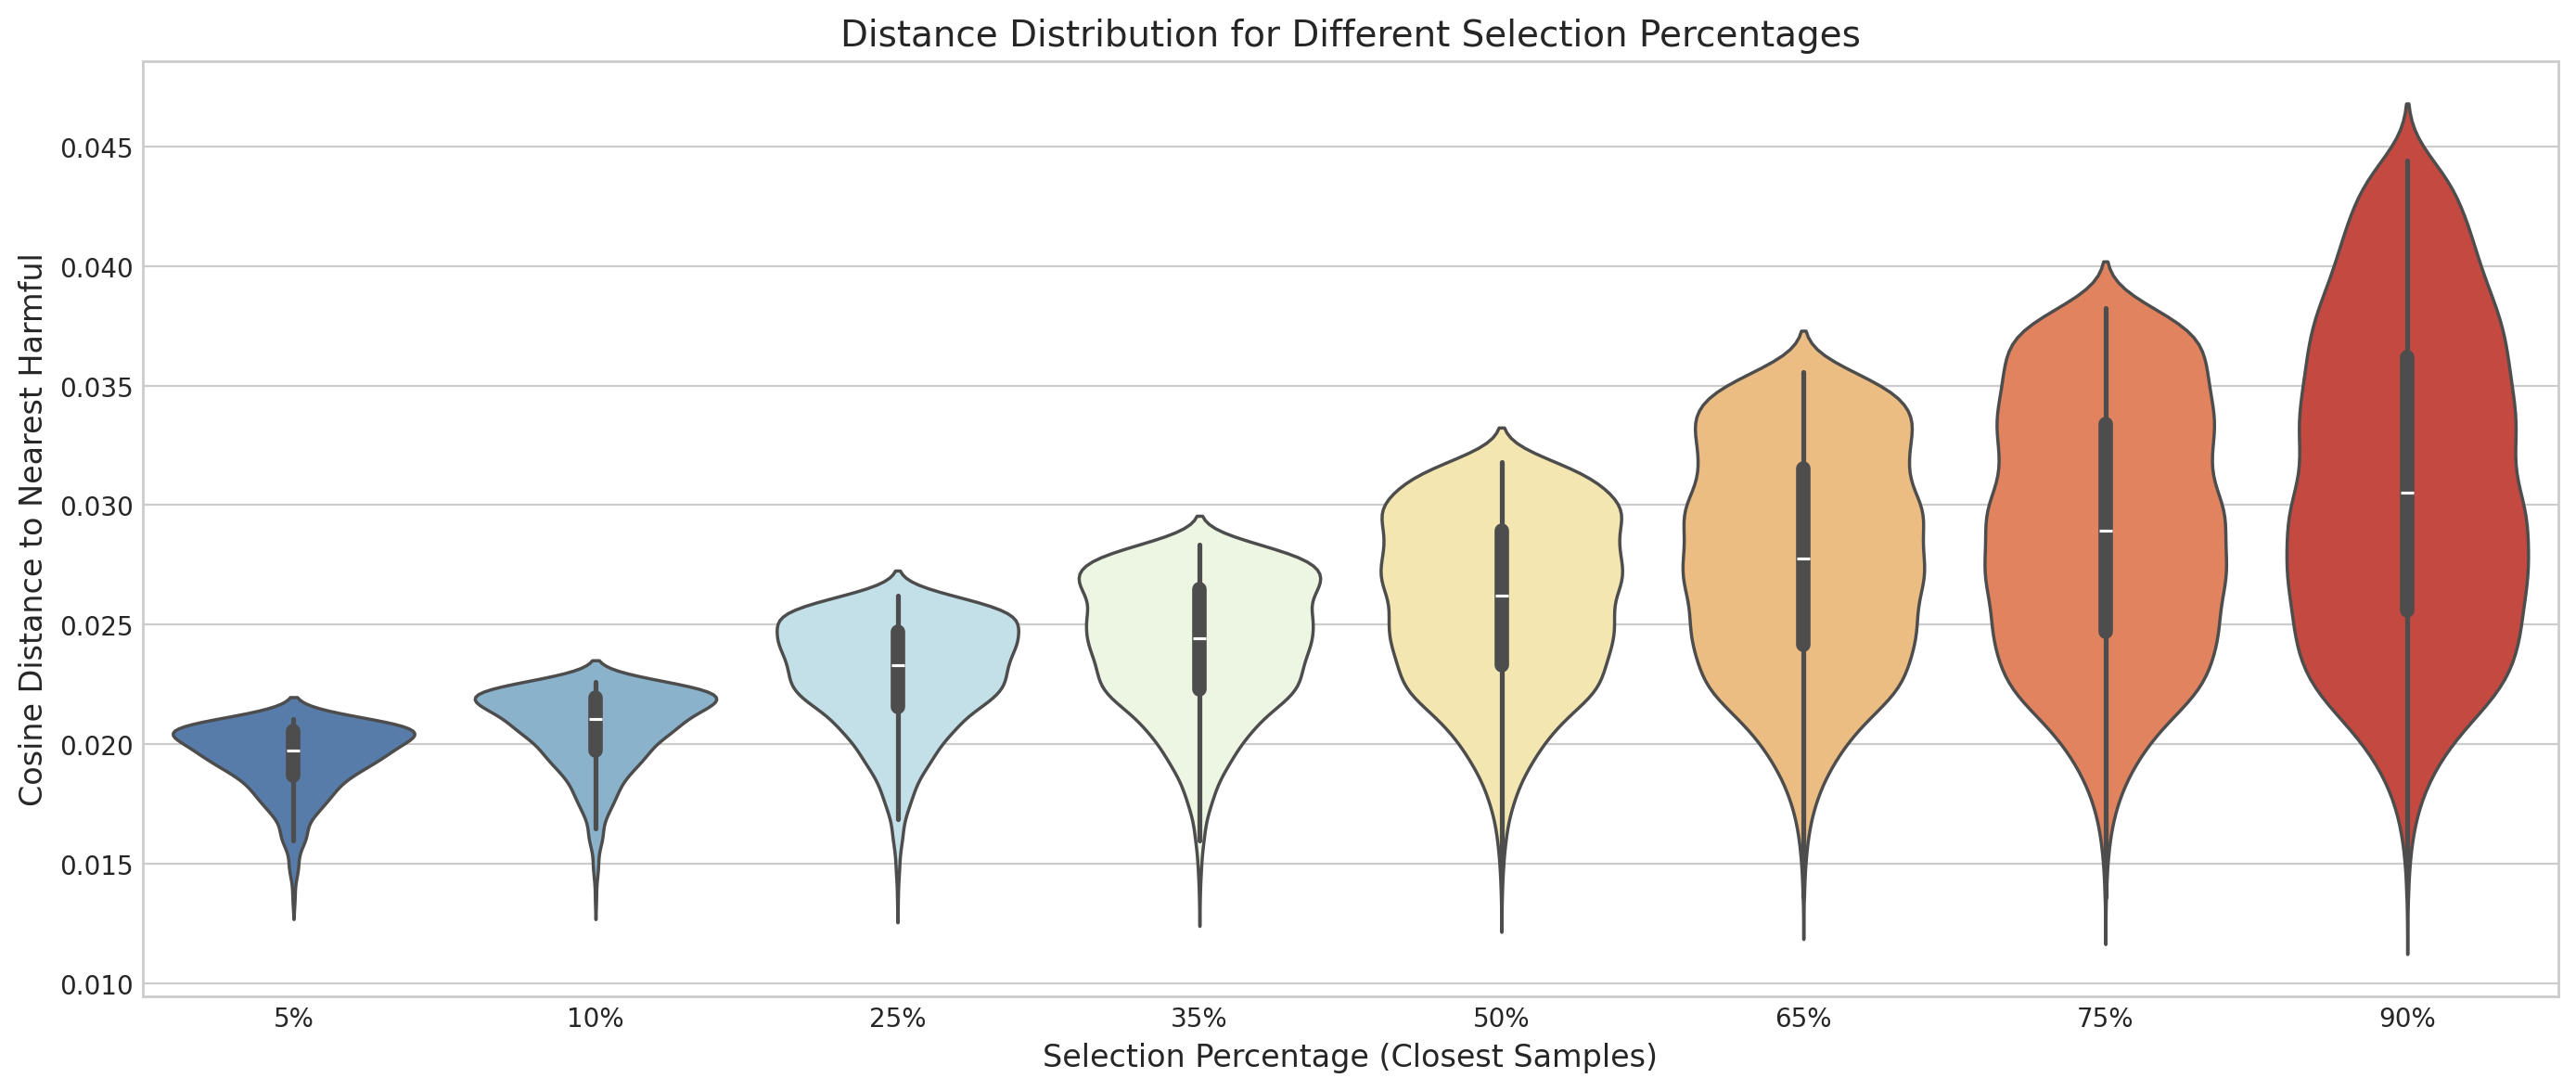

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(data=selection_df, x='Percentage', y='Distance', ax=ax, palette='RdYlBu_r')
ax.set_xlabel('Selection Percentage (Closest Samples)', fontsize=12)
ax.set_ylabel('Cosine Distance to Nearest Harmful', fontsize=12)
ax.set_title('Distance Distribution for Different Selection Percentages', fontsize=14)

plt.tight_layout()
plt.savefig('figures/violin_selection_percentages.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. 3D Visualization (Optional)

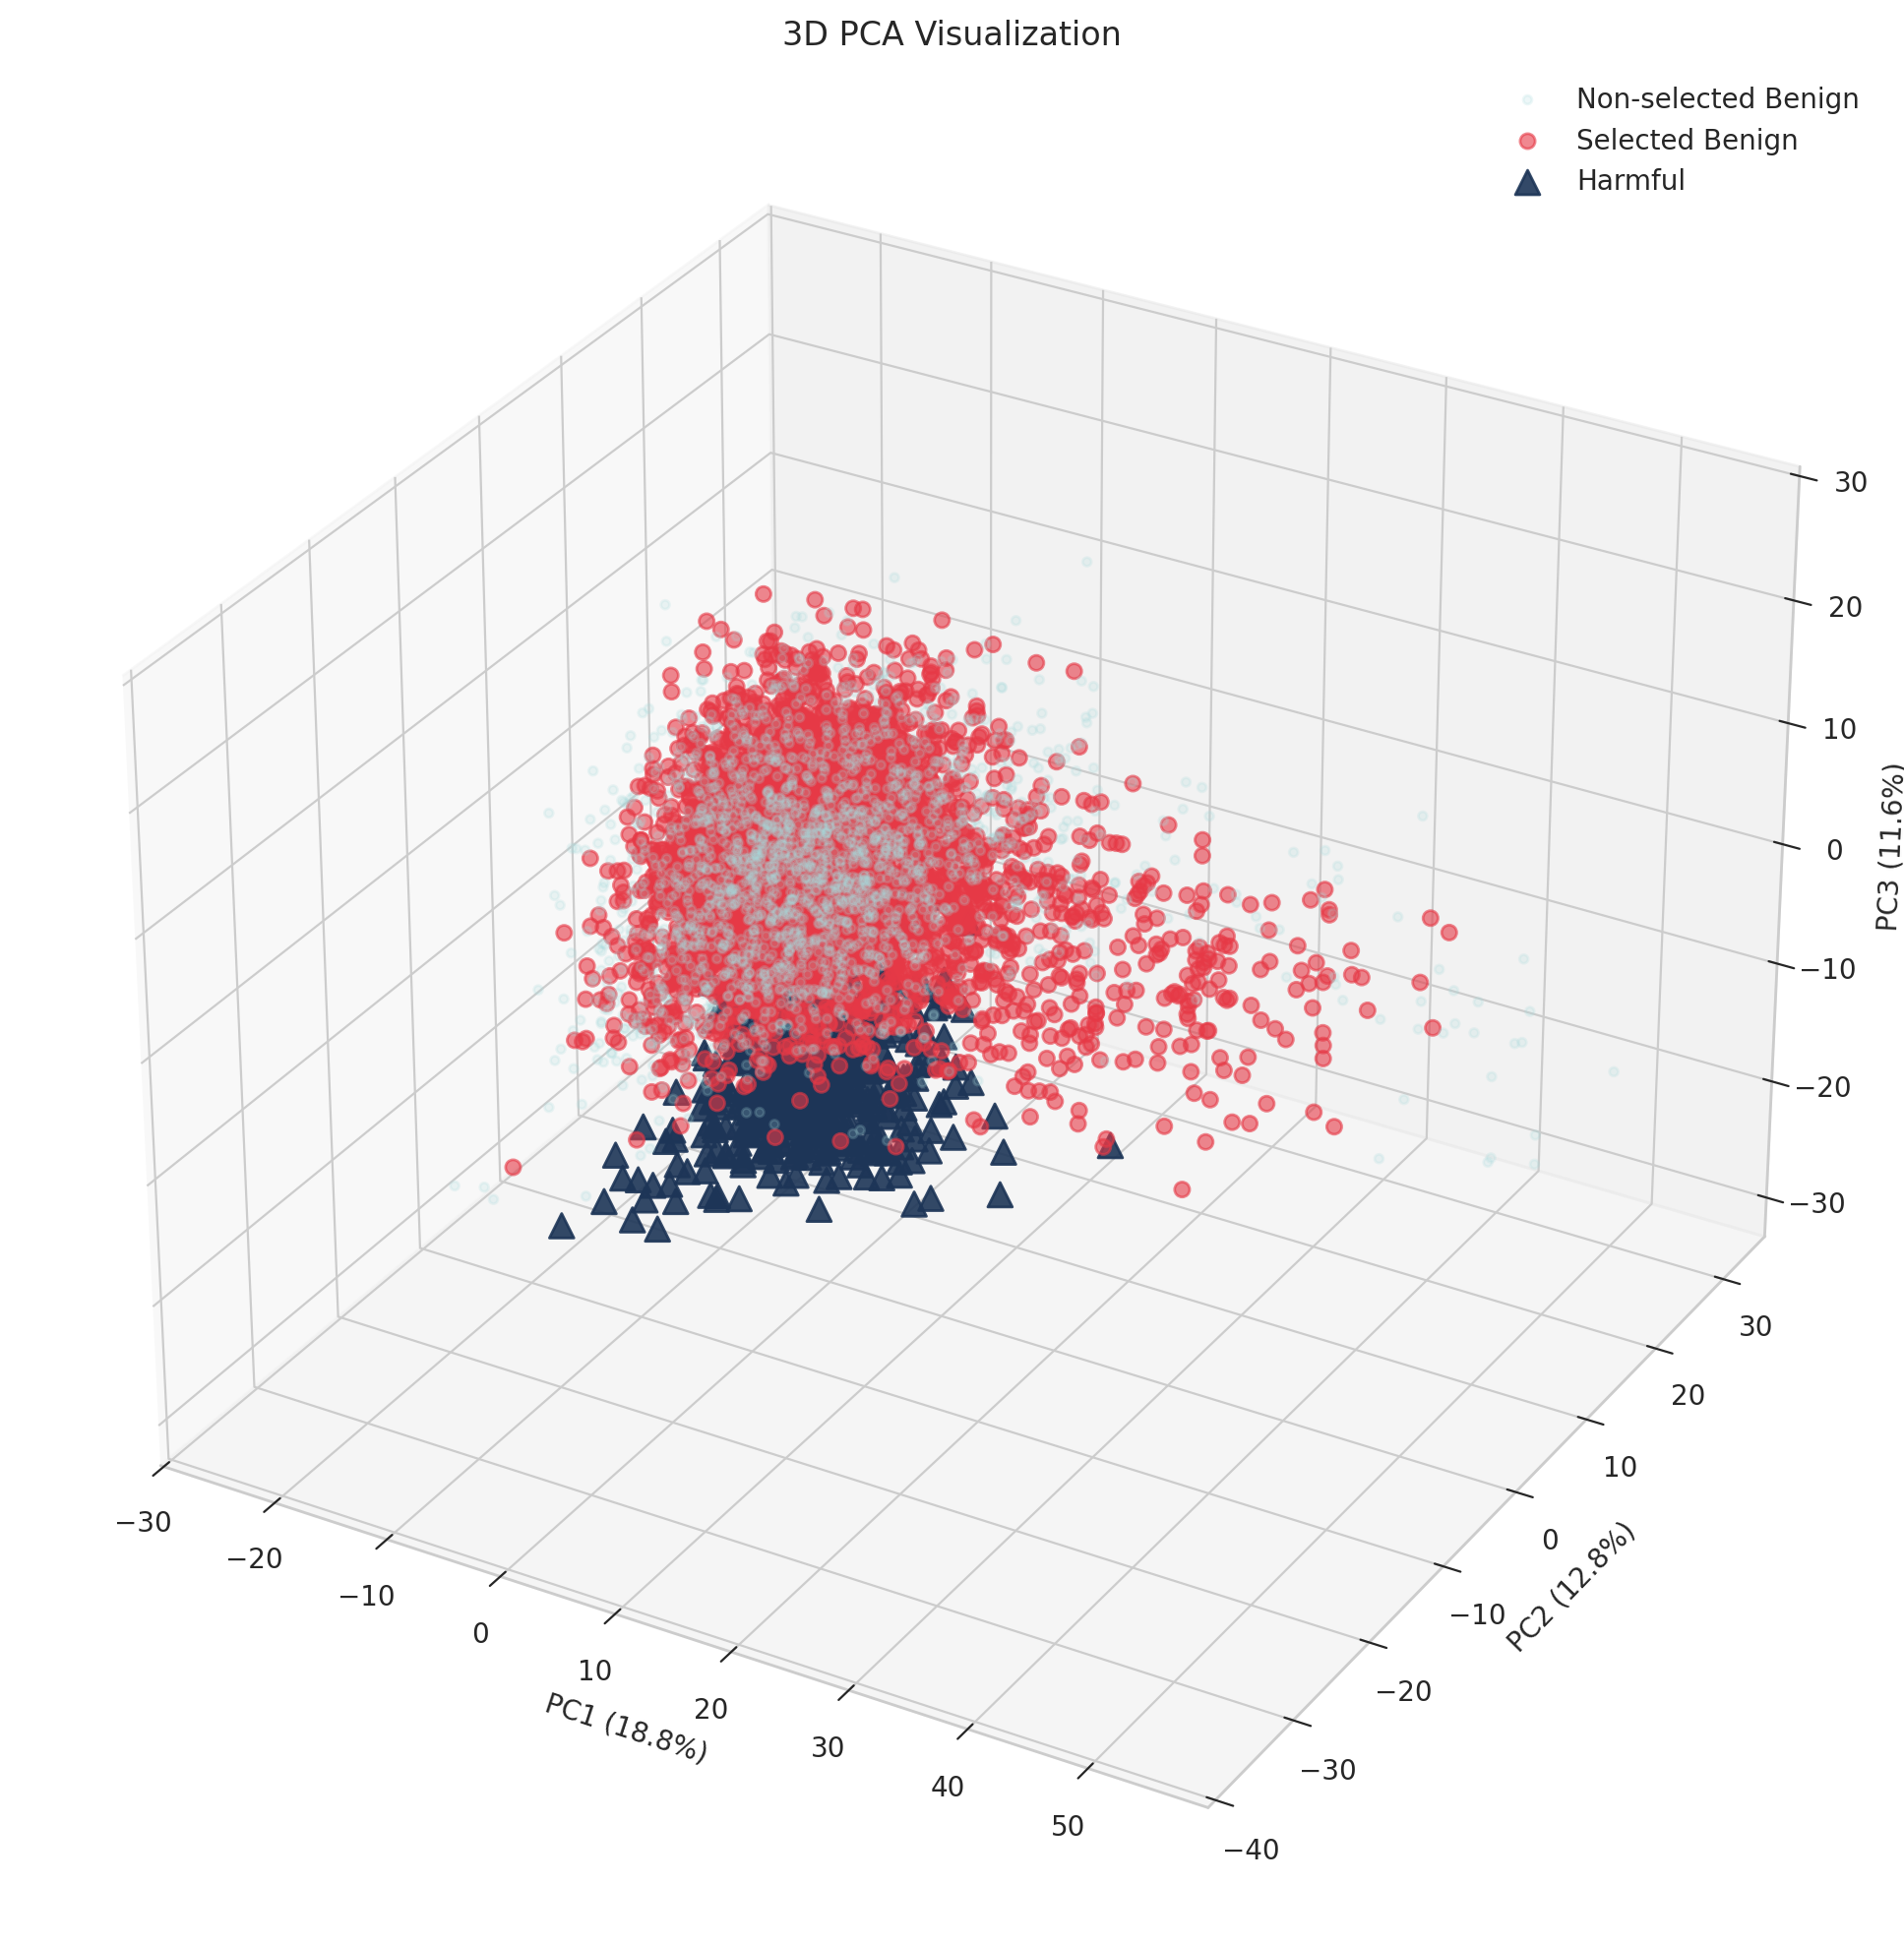

In [25]:
from mpl_toolkits.mplot3d import Axes3D

# 3D PCA
pca_3d = PCA(n_components=3)
embeddings_pca_3d = pca_3d.fit_transform(all_embeddings)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

colors = ['#a8dadc', '#e63946', '#1d3557']
labels_names = ['Non-selected Benign', 'Selected Benign', 'Harmful']
markers = ['o', 'o', '^']
sizes = [10, 30, 80]
alphas = [0.2, 0.6, 0.9]

for i, (label_name, color, marker, size, alpha) in enumerate(zip(labels_names, colors, markers, sizes, alphas)):
    mask = labels == i
    ax.scatter(embeddings_pca_3d[mask, 0], embeddings_pca_3d[mask, 1], embeddings_pca_3d[mask, 2],
               c=color, label=label_name, s=size, alpha=alpha, marker=marker)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('3D PCA Visualization')
ax.legend()

plt.tight_layout()
plt.savefig('figures/pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Save All Figures List

In [26]:
print("\n" + "="*60)
print("Generated Figures:")
print("="*60)
figures = [
    'figures/distance_distributions.png',
    'figures/tsne_embeddings.png',
    'figures/umap_embeddings.png (if UMAP installed)',
    'figures/distance_heatmap.png',
    'figures/nearest_neighbor_analysis.png',
    'figures/pca_variance.png',
    'figures/pca_embeddings.png',
    'figures/threshold_analysis.png',
    'figures/violin_selection_percentages.png',
    'figures/pca_3d.png',
    'figures/embedding_analysis_summary.csv'
]
for fig in figures:
    print(f"  - {fig}")


Generated Figures:
  - figures/distance_distributions.png
  - figures/tsne_embeddings.png
  - figures/umap_embeddings.png (if UMAP installed)
  - figures/distance_heatmap.png
  - figures/nearest_neighbor_analysis.png
  - figures/pca_variance.png
  - figures/pca_embeddings.png
  - figures/threshold_analysis.png
  - figures/violin_selection_percentages.png
  - figures/pca_3d.png
  - figures/embedding_analysis_summary.csv
